In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from inputs_for_plots import *

In [2]:
def prepare_error_dataframe(ols_est, errors_list, column_names):
    """Creates a DataFrame with all error values in a long format."""
    df_list = [pd.DataFrame(np.abs(ols_est), columns=["Biased OLS"])]
    for errors, col_name in zip(errors_list, column_names):
        df_list.append(pd.DataFrame(errors["error"], columns=[col_name]))
    return pd.concat(df_list, axis=1)


## Plot increase in confounding

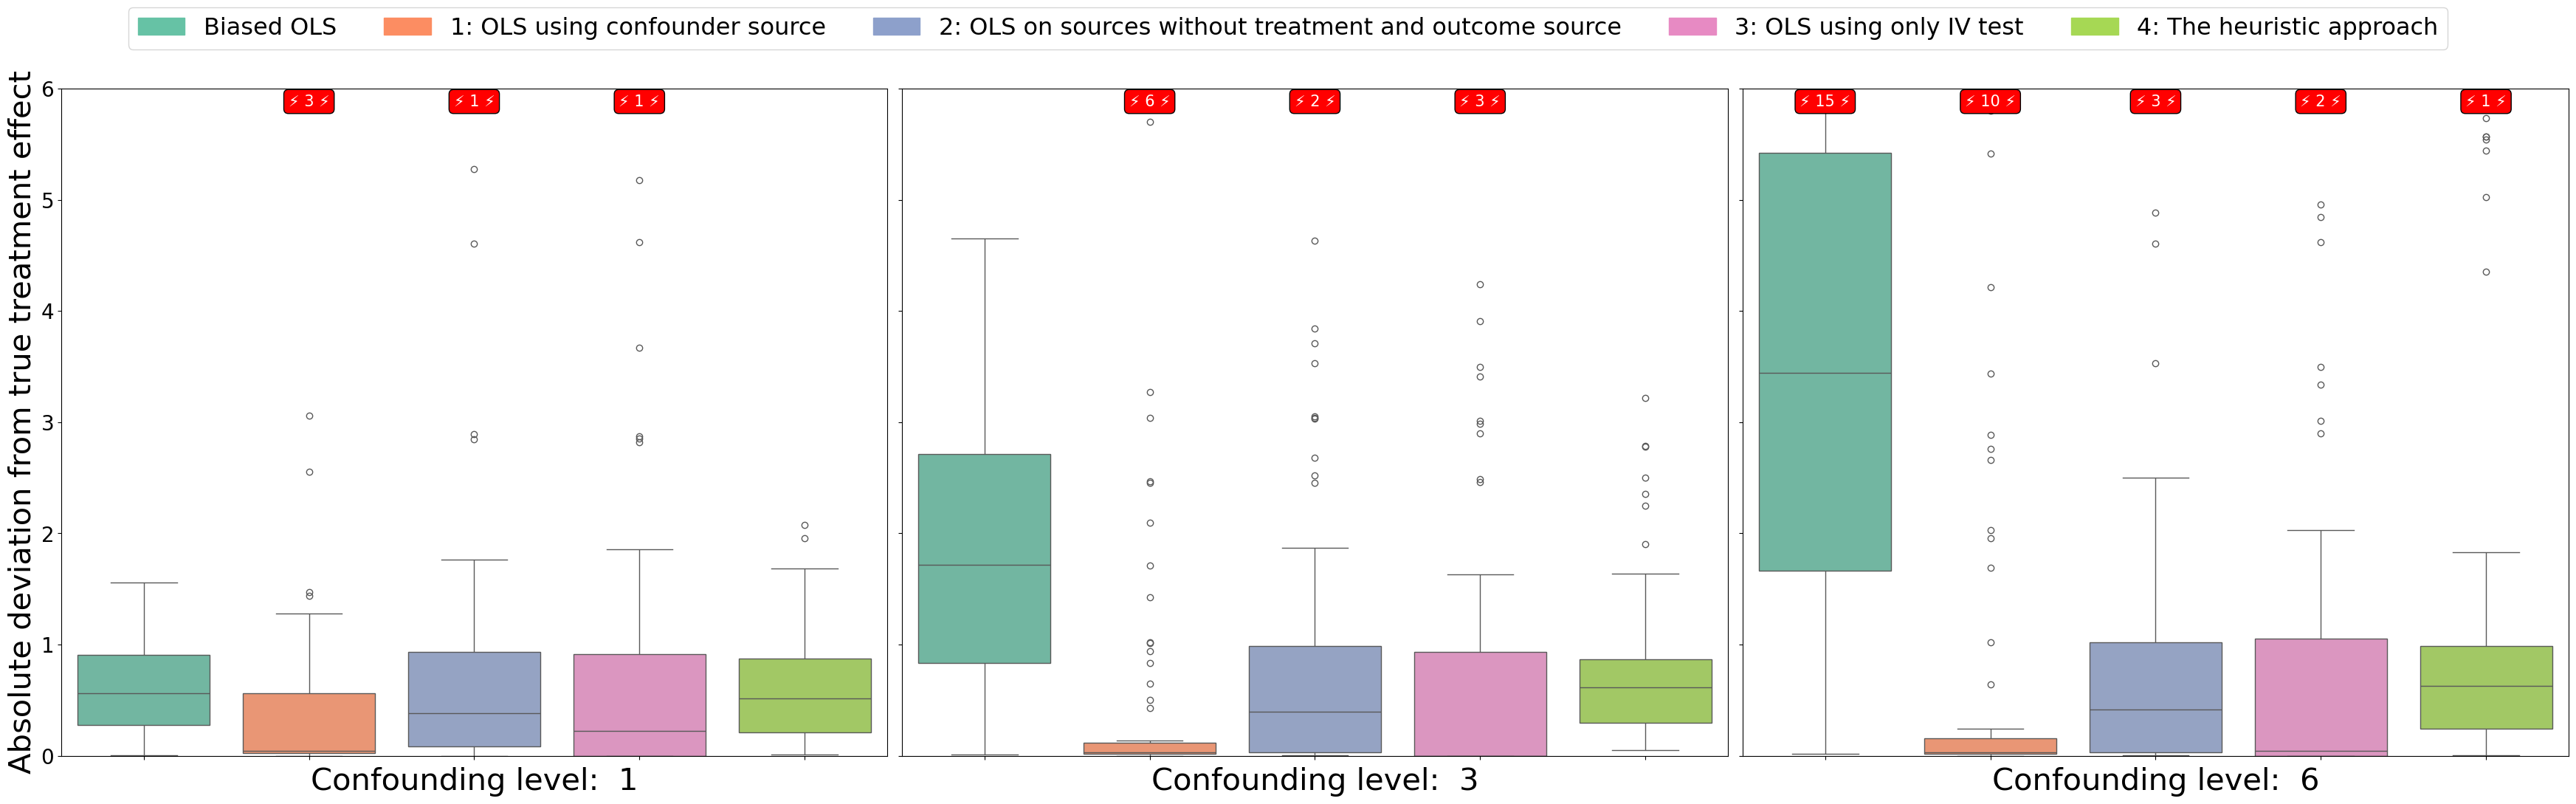

In [3]:

def main_plot(confounder_levels):
    """Generates plots for different confounder levels."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(confounder_levels), figsize=(35, 10), sharey=True)
    
    
    for i, level in enumerate(confounder_levels):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_confounding_levels/data/", name=f"true_mixing_large_conf_{level}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_confounding_levels/data/", name=f"data_obs_large_conf_{level}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)
        
        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_cn_{level}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_cn_{level}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_cn_{level}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)

        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_cn_{level}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)
        
        err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources,errors_iv_only, errors_nonsense ], ["1: OLS using confounder source", "2: OLS on sources without treatment and outcome source"
                                                                                                                        , "3: OLS using only IV test", "4: The heuristic approach"])
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[level] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        palette = plot_errors(err, rmse, mae, std, axes[i], level, "Confounding level", y_lim=6)
    
    # add one legend for all plots
    add_one_legend(fig, err, palette)
    plt.tight_layout()
    plt.show()
    return method_summary

# Example usage
confounder_levels = [1, 3, 6]
method_summary = main_plot(confounder_levels)


In [4]:
print_method_summary(method_summary)

Level 1
       Biased OLS  1: OLS using confounder source  \
RMSE     0.688614                        1.832042   
MAE      0.585996                        0.612863   
STD      0.687864                        1.823154   
Cases  100.000000                       87.000000   

       2: OLS on sources without treatment and outcome source  \
RMSE                                            1.565732        
MAE                                             0.753034        
STD                                             1.565423        
Cases                                          97.000000        

       3: OLS using only IV test  4: The heuristic approach  
RMSE                    0.731443                   1.662679  
MAE                     0.592085                   0.755280  
STD                     0.708569                   1.662184  
Cases                  90.000000                  89.000000  
Level 3
       Biased OLS  1: OLS using confounder source  \
RMSE     2.060265            

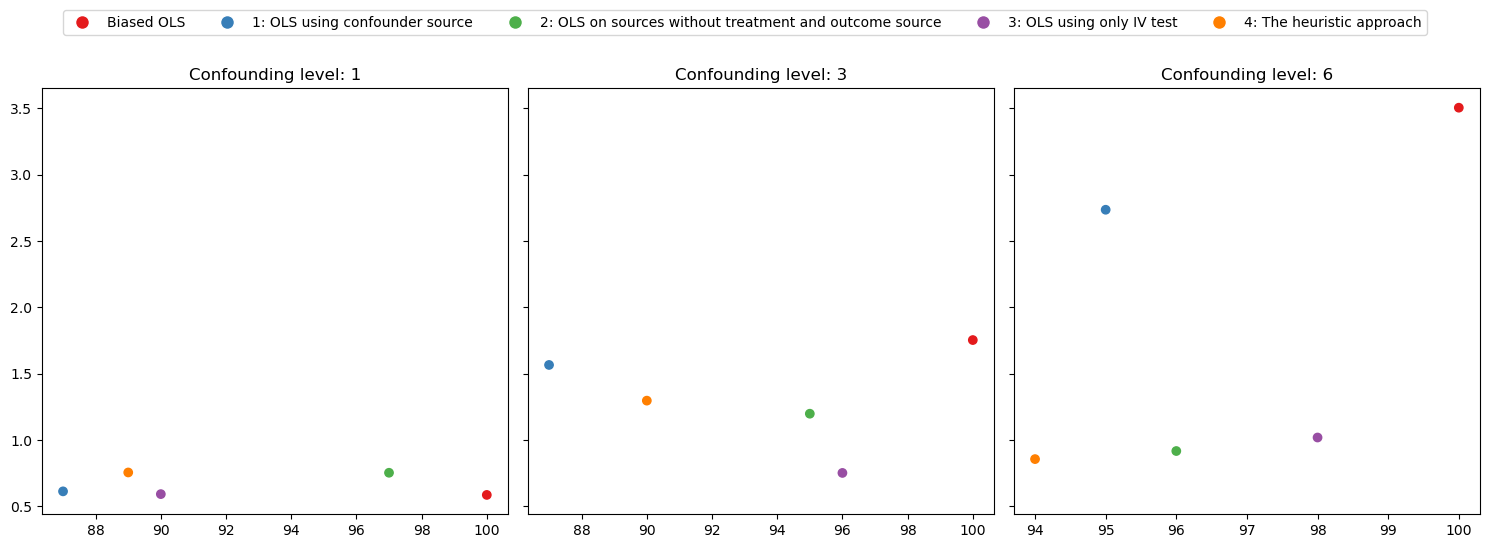

In [5]:
plot_cases_vs_performance(method_summary, "mae", "Confounding level")

## Plot different number of covariates

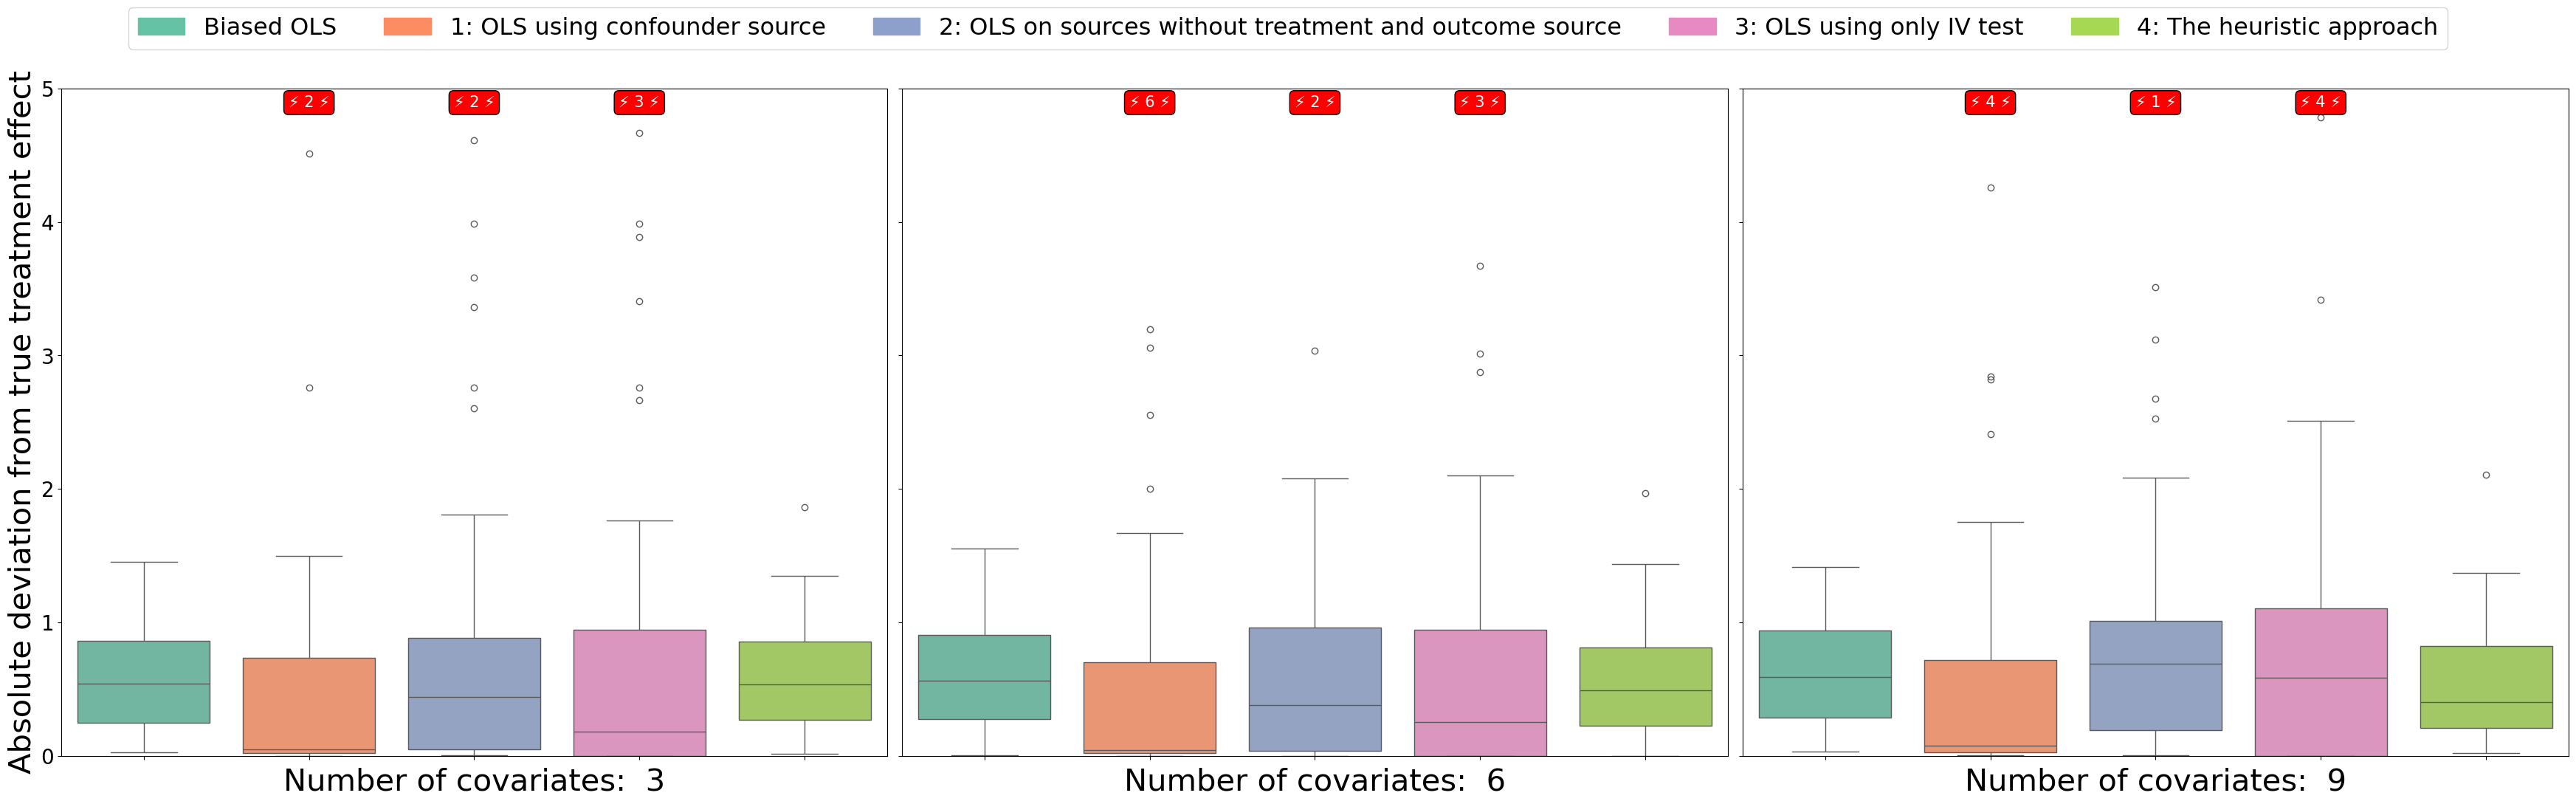

In [6]:
def main_plot(number_of_covariates):
    """Generates plots for different number of covariates."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(confounder_levels), figsize=(35, 10), sharey=True)
    
    for i, covs in enumerate(number_of_covariates):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_numbers_of_covariates/data/", name=f"true_mixing_covs_{covs}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_numbers_of_covariates/data/", name=f"data_obs_covs_{covs}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)


        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_number_of_covs_{covs}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_number_of_covs_{covs}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_number_of_covs_{covs}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)
        
        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_number_of_covs_{covs}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)

        
        err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources,errors_iv_only, errors_nonsense ], ["1: OLS using confounder source", "2: OLS on sources without treatment and outcome source"
                                                                                                                        , "3: OLS using only IV test", "4: The heuristic approach"])
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[covs] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        palette = plot_errors(err, rmse, mae, std, axes[i], covs, "Number of covariates", y_lim=5)
        
    
    add_one_legend(fig, err, palette)
    plt.tight_layout()
    plt.show()
    return method_summary

# Example usage
number_of_covariates = [3, 6, 9]
method_summary = main_plot(number_of_covariates)




In [7]:
print_method_summary(method_summary)

Level 3
       Biased OLS  1: OLS using confounder source  \
RMSE     0.694980                        3.541848   
MAE      0.572190                        0.892766   
STD      0.692949                        3.515966   
Cases  100.000000                       78.000000   

       2: OLS on sources without treatment and outcome source  \
RMSE                                            2.555458        
MAE                                             0.974927        
STD                                             2.548928        
Cases                                          99.000000        

       3: OLS using only IV test  4: The heuristic approach  
RMSE                    0.686724                   2.975271  
MAE                     0.573727                   1.100387  
STD                     0.681452                   2.944456  
Cases                  88.000000                  82.000000  
Level 6
       Biased OLS  1: OLS using confounder source  \
RMSE     0.688614            

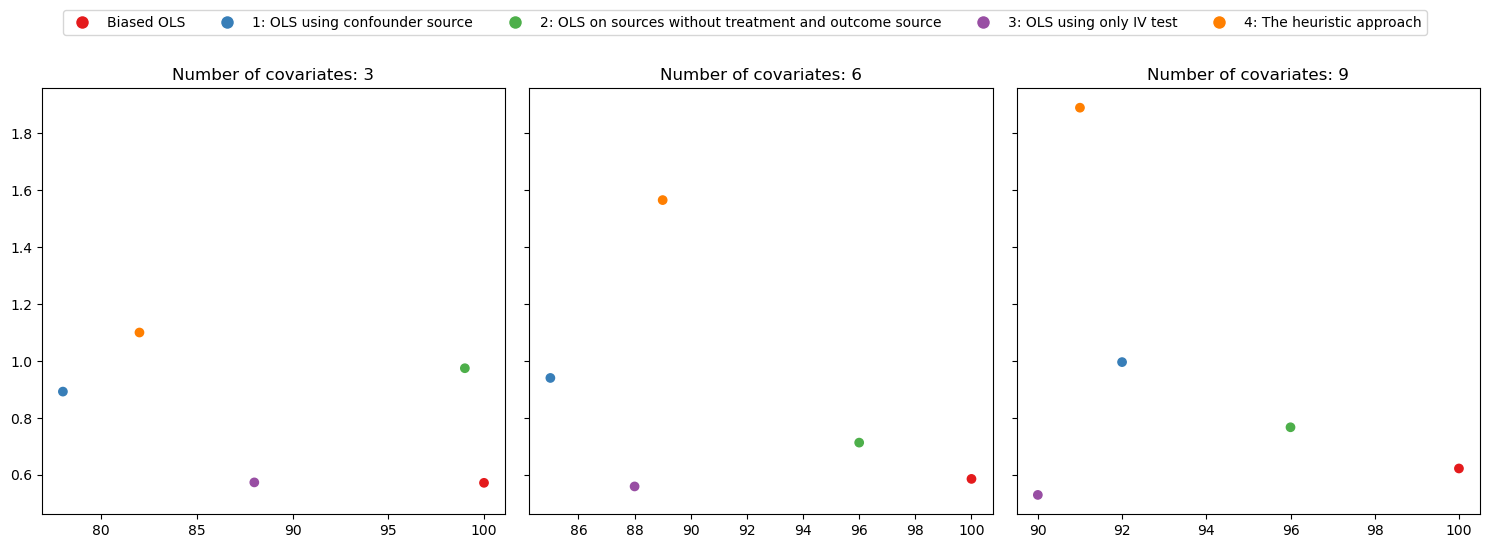

In [8]:
plot_cases_vs_performance(method_summary, "mae", "Number of covariates")

## Plot different sample sizes

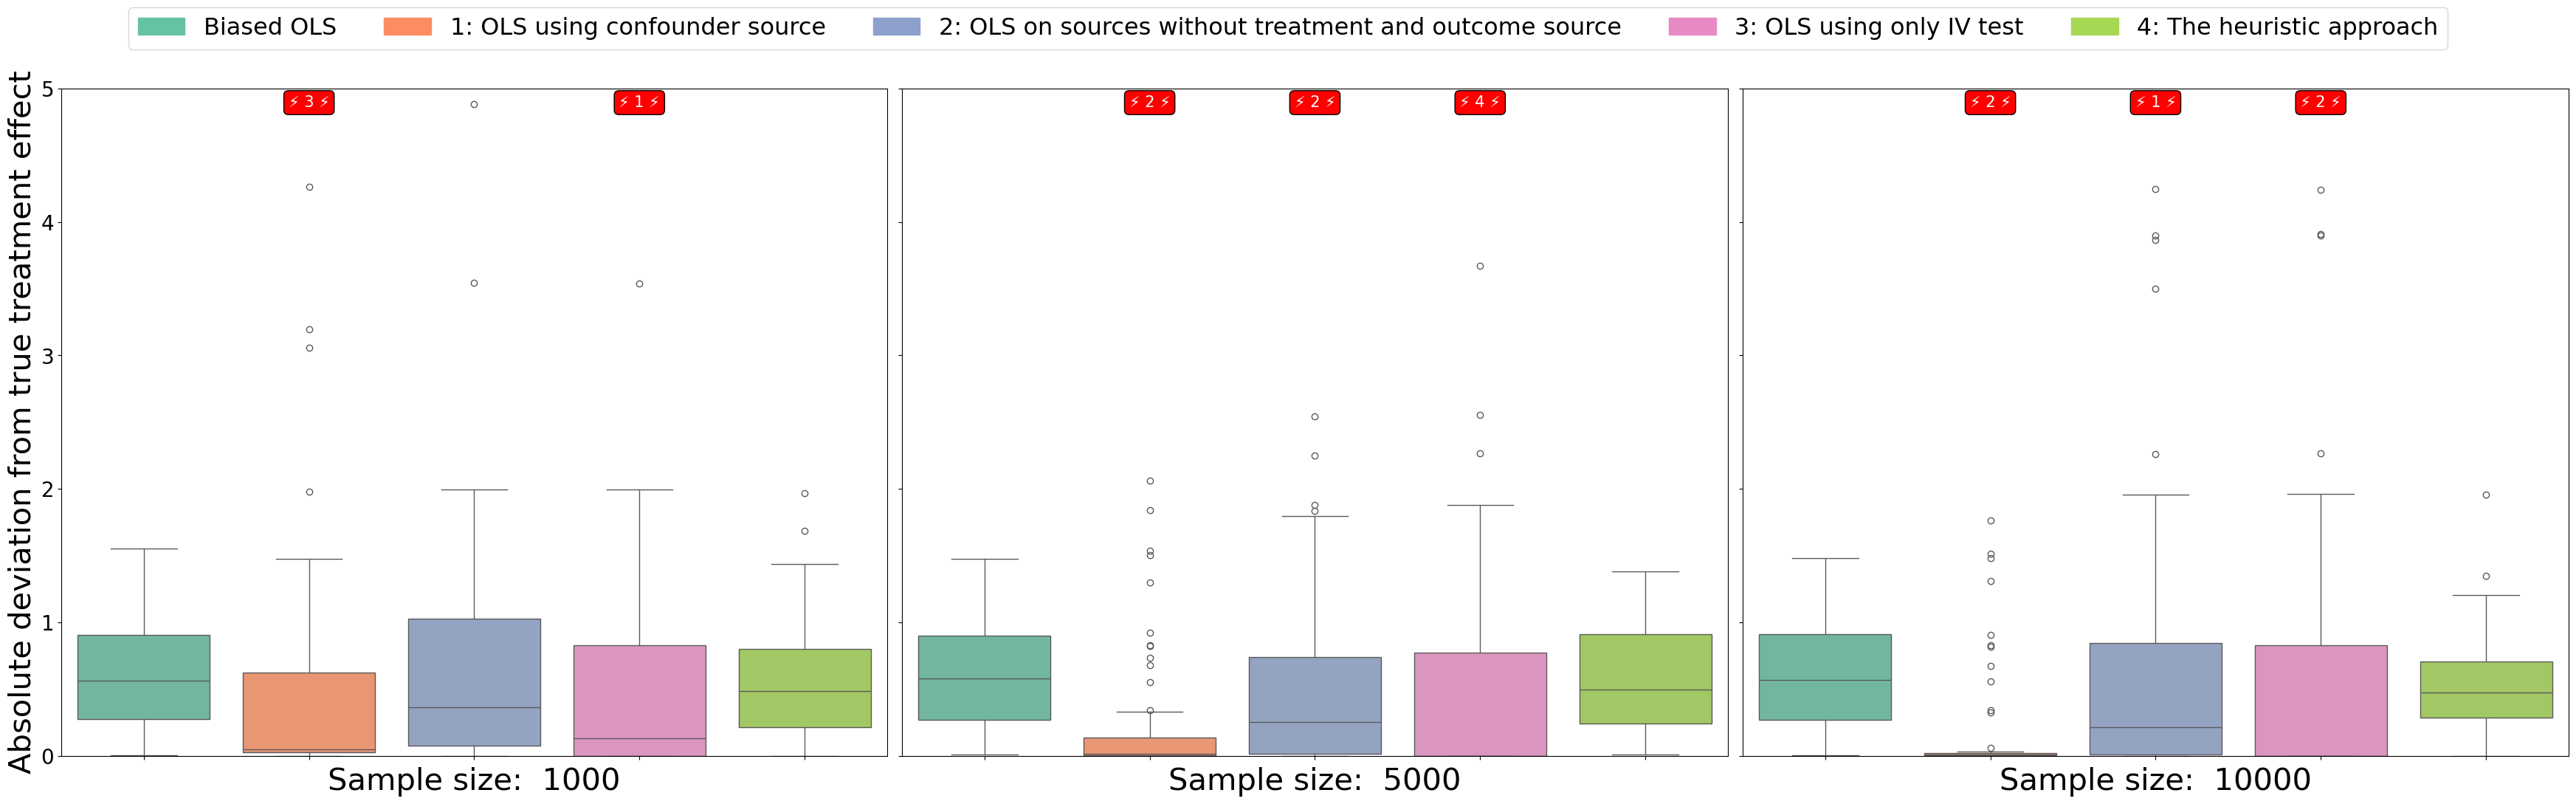

In [9]:
def main_plot(ns):
    """Generates plots for different number of sample sizes."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(confounder_levels), figsize=(35, 10), sharey=True)
    
    for i, n in enumerate(ns):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/differen_sample_sizes/data/", name=f"true_mixing_n:{n}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/differen_sample_sizes/data/", name=f"data_obs_n:{n}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)


        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_n:{n}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_n:{n}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_n:{n}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)
        
        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_n:{n}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)

        
        
        err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources,errors_iv_only, errors_nonsense ], ["1: OLS using confounder source", "2: OLS on sources without treatment and outcome source"
                                                                                                                        , "3: OLS using only IV test", "4: The heuristic approach"])  
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[n] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        palette = plot_errors(err, rmse, mae, std, axes[i], n,"Sample size", y_lim=5)
        
        
    
    add_one_legend(fig, err, palette, size )
    plt.tight_layout()
    plt.show()
    return method_summary

# Example usage
ns = [1000, 5000, 10000]
method_summary = main_plot(ns)




In [10]:
print_method_summary(method_summary)

Level 1000
       Biased OLS  1: OLS using confounder source  \
RMSE     0.688614                        1.452720   
MAE      0.585996                        0.608864   
STD      0.687864                        1.449405   
Cases  100.000000                       85.000000   

       2: OLS on sources without treatment and outcome source  \
RMSE                                            0.988199        
MAE                                             0.632940        
STD                                             0.979425        
Cases                                          98.000000        

       3: OLS using only IV test  4: The heuristic approach  
RMSE                    0.676536                   1.164792  
MAE                     0.544164                   0.590979  
STD                     0.670809                   1.161690  
Cases                  90.000000                  87.000000  
Level 5000
       Biased OLS  1: OLS using confounder source  \
RMSE     0.692705      

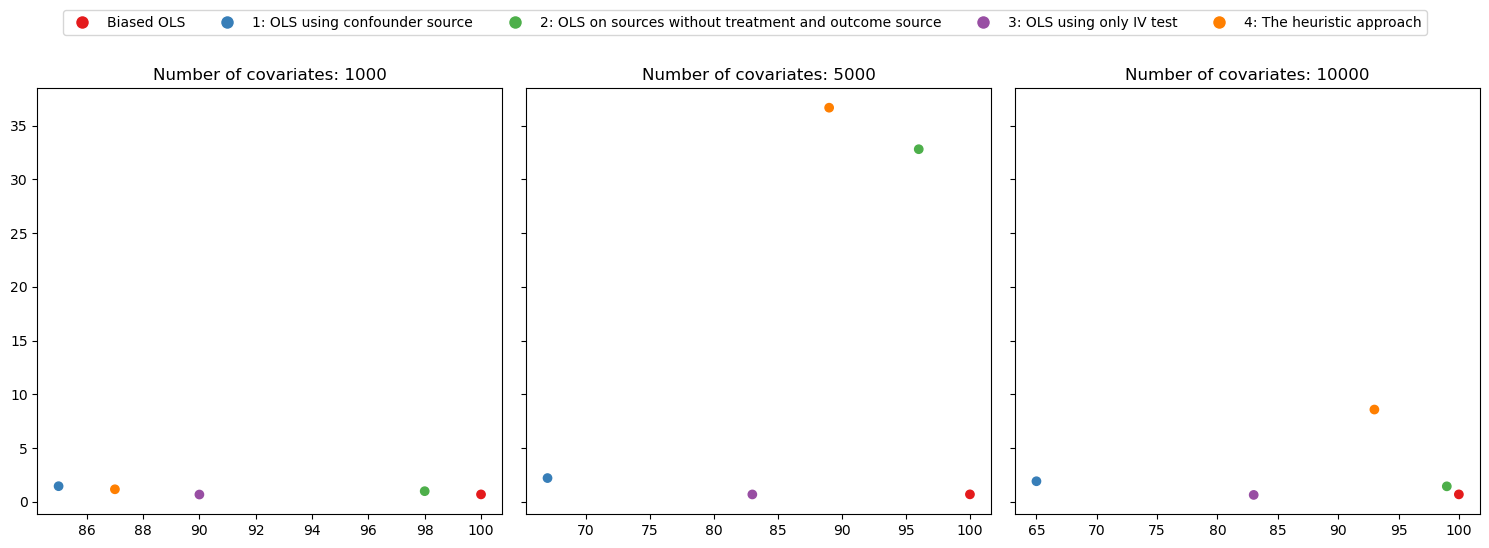

In [11]:
plot_cases_vs_performance(method_summary, "rmse", "Number of covariates")

 # Plot bounded treatment effect

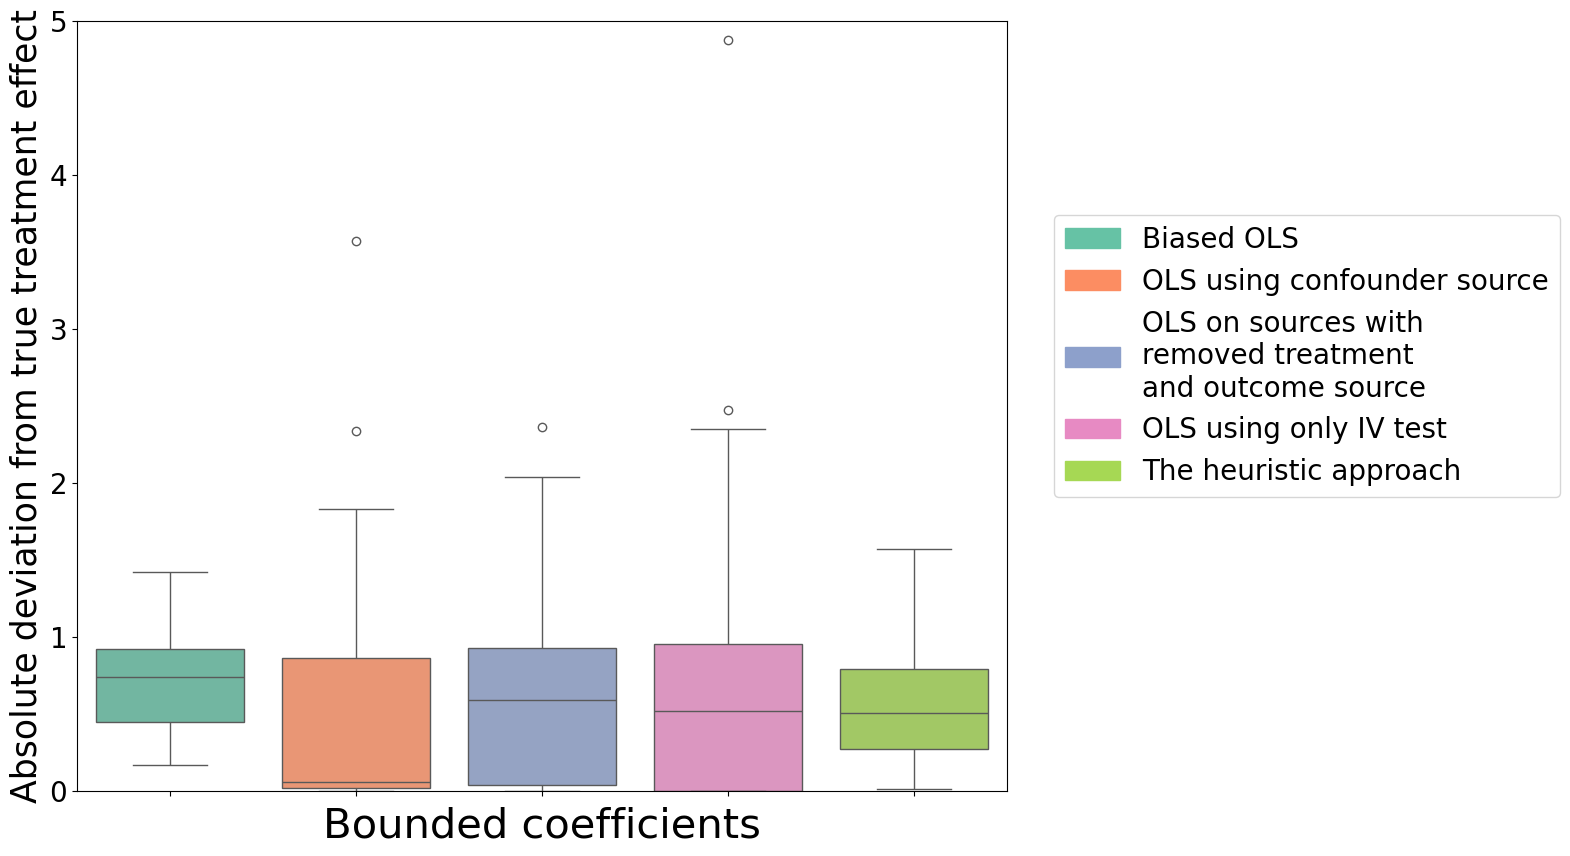

Bounded treatment effect
                                                        RMSE       MAE  \
Biased OLS                                          0.779054  0.713521   
OLS using confounder source                         0.784616  0.473511   
OLS on sources with \nremoved treatment \nand o...  0.841481  0.626732   
OLS using only IV test                              0.660312  0.559038   
The heuristic approach                              0.957798  0.605432   

                                                         STD  
Biased OLS                                          0.777512  
OLS using confounder source                         0.784616  
OLS on sources with \nremoved treatment \nand o...  0.835685  
OLS using only IV test                              0.659115  
The heuristic approach                              0.957542  


In [12]:
def plot_errors_bounded(err, rmse, mae, std,ax, y_lim = 5):
    """Creates boxplots and adds legend with RMSE, MAE, and STD."""
    df_long = err.melt(var_name="variable", value_name="value").dropna()
    palette = sns.color_palette("Set2", n_colors=len(df_long["variable"].unique()))
    boxplot = sns.boxplot(data=df_long, y="value", x="variable", hue="variable", ax=ax, palette=palette, legend=False)
    
    ax.set_xlabel(f"Bounded coefficients", fontsize=30)
    ax.set_ylabel("Absolute deviation from true treatment effect", fontsize=25)

    ax.set_xticklabels([])  
    ax.tick_params(axis='both', which='major', labelsize=20)

    ax.set_ylim((0, y_lim))


    outlier_counts = df_long[df_long["value"] > y_lim].groupby("variable").size()


    positions = ax.get_xticks()  
    for pos, variable in zip(positions, df_long['variable'].unique()):
        count = outlier_counts.get(variable, 0)  
        

        if count > 0:

            ax.text(
                pos, y_lim -.05, f"⚡ {count} ⚡", 
                ha='center', va='top', 
                fontsize=15, color="white", 
                bbox=dict(facecolor='red', edgecolor='black', boxstyle='round,pad=0.3')
            )
            
    return palette

true_treatment = get_true_treatment_effect(path="data_generation/bounded_treatment_effect/data/", name="true_mixing_init_flipp_")
ols_est = calculate_ols_estimate(path=f"data_generation/bounded_treatment_effect/data/", name= "data_obs_init_flipp_")
ols_est = np.array(ols_est) - np.array(true_treatment)




errors_confounder = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_bounded_treatment.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
errors_7_sources = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_bounded_treatment.csv", "estimated_treatment_on_sources", "true_treatment_effect")
errors_nonsense = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_bounded_treatment.csv", "mistaken_scheme", "true_treatment_effect")
errors_iv_only = load_and_calculate_errors("../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_bounded.csv", "iv_only_effect", "true_treatment_effect")

rmse, mae, std = [], [], []
gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)
gather_statistics(errors_confounder, rmse, mae, std)
gather_statistics(errors_7_sources, rmse, mae, std)
gather_statistics(errors_nonsense, rmse, mae, std)
gather_statistics(errors_iv_only, rmse, mae, std)

err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources,errors_iv_only, errors_nonsense, ], ["OLS using confounder source", "OLS on sources with \nremoved treatment \nand outcome source", 
                                                                                                                        "OLS using only IV test", "The heuristic approach"])
no_of_cases = {col: 100 - err[col].isna().sum() for col in err.columns}
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
palette = plot_errors_bounded(err, rmse, mae, std, ax)  
handles = [
        mpatches.Patch(color=palette[i], label=f"{err.columns[i]}")
        for i in range(len(err.columns))
    ]
    
fig.legend(handles=handles, loc="upper center", ncol=1, fontsize=20, bbox_to_anchor=(1.15, .7))
plt.show()

# print metric summary
print("Bounded treatment effect")
print(pd.DataFrame({"RMSE": rmse, "MAE": mae, "STD": std}, index=err.columns))

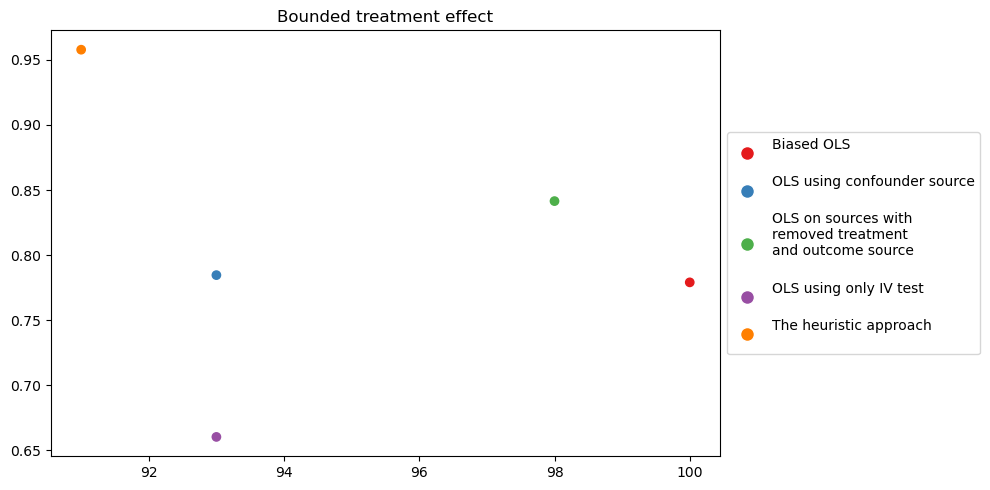

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), sharey=True)



methods = no_of_cases.keys()
cases = no_of_cases.values()
palette = sns.color_palette("Set1", len(methods))
ax.scatter(cases, rmse, c=palette, label=methods)

ax.set_title("Bounded treatment effect")    

legend_labels = list(methods)
legend_colors = palette[:len(legend_labels)]
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in legend_colors]

# Add line breaks after each method in the legend
legend_labels = [label + '\n' for label in legend_labels]

# Position the legend to the left of the plot
ax.legend(handles, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

plt.tight_layout()
plt.show()
